# 1. Import & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 2. Daten einlesen

In [2]:
file_path = "../data/Number_of_fires_by_month.csv"
# CSV mit Semikolon-Trenner einlesen
df = pd.read_csv(file_path, sep=";", header=1, encoding="ISO-8859-1")

# 3. Datenbereinigung

In [3]:
# Spaltennamen aufräumen
df.columns = df.columns.str.strip()

# "Data Qualifier"-Spalte entfernen
df = df.loc[:, ~df.columns.str.contains('Data Qualifier', case=False)]

# Alle 'Unspecified'-Einträge in 'Month' löschen
df = df[df["Month"].notna()]
df = df[~df['Month'].str.contains("Unspecified", case=False, na=False)]

# Alle leeren Werte durch NaN ersetzen
df = df.replace(["", " ",], np.nan)

# "Wide" → "Long" Format
df_long = df.melt(
    id_vars=["Jurisdiction", "Month"],  # diese Spalten bleiben fix
    var_name="Year",                    # Name der neuen "Jahr"-Spalte
    value_name="Number_fires"                  # Name für die Werte (z. B. Anzahl Brände)
)

#Month als 1–12 umwandeln
df_long["Month"] = pd.to_datetime(df_long["Month"], format="%B").dt.month

In [4]:
# Für Korrelationsanalyse Rohdatei speichern
#output_path = "../data/cleaned_wlags_Number_of_fires_by_month.csv"
#df_long.to_csv(output_path, index=False)

# 4. Explorative Visualisierung

Basisinfo

In [5]:
print(df_long.info())
print(df_long.describe())

# Fehlende Werte je Spalte
print(df_long.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4624 entries, 0 to 4623
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Jurisdiction  4624 non-null   object 
 1   Month         4624 non-null   int32  
 2   Year          4624 non-null   object 
 3   Number_fires  3234 non-null   float64
dtypes: float64(1), int32(1), object(2)
memory usage: 126.6+ KB
None
             Month  Number_fires
count  4624.000000   3234.000000
mean      6.698529     71.323748
std       3.350779    131.497892
min       1.000000      0.000000
25%       4.000000      4.000000
50%       7.000000     22.000000
75%      10.000000     83.750000
max      12.000000   2118.000000
Jurisdiction       0
Month              0
Year               0
Number_fires    1390
dtype: int64


Zeitreihen Visualisierung

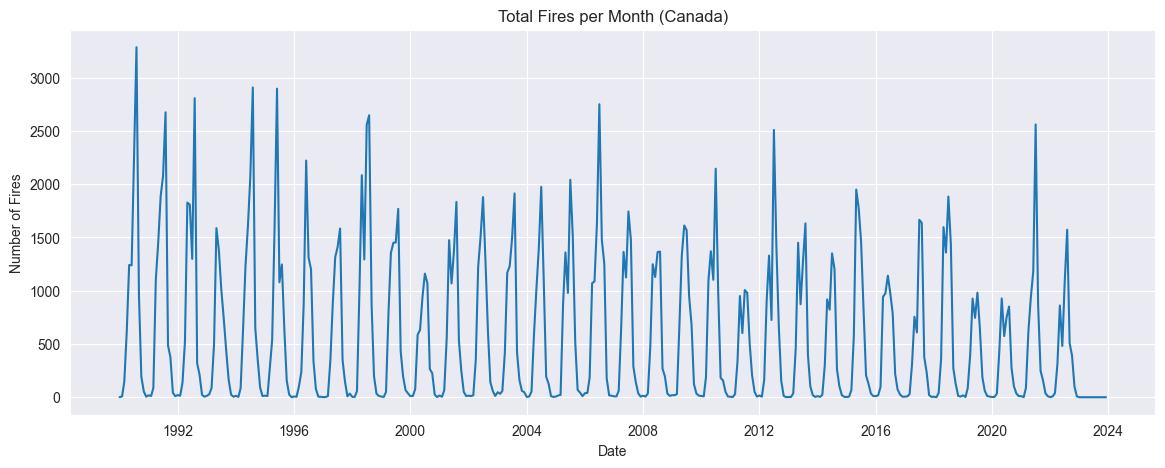

In [6]:
# Gesamtzeitreihe
ts_total = (
    df_long.groupby(["Year", "Month"])["Number_fires"]
    .sum()
    .reset_index()
)
ts_total["Date"] = pd.to_datetime(ts_total["Year"].astype(str) + "-" + ts_total["Month"].astype(str))

plt.figure(figsize=(14,5))
plt.plot(ts_total["Date"], ts_total["Number_fires"])
plt.title("Total Fires per Month (Canada)")
plt.xlabel("Date")
plt.ylabel("Number of Fires")
plt.show()


Zeitreihen Jurisdiction

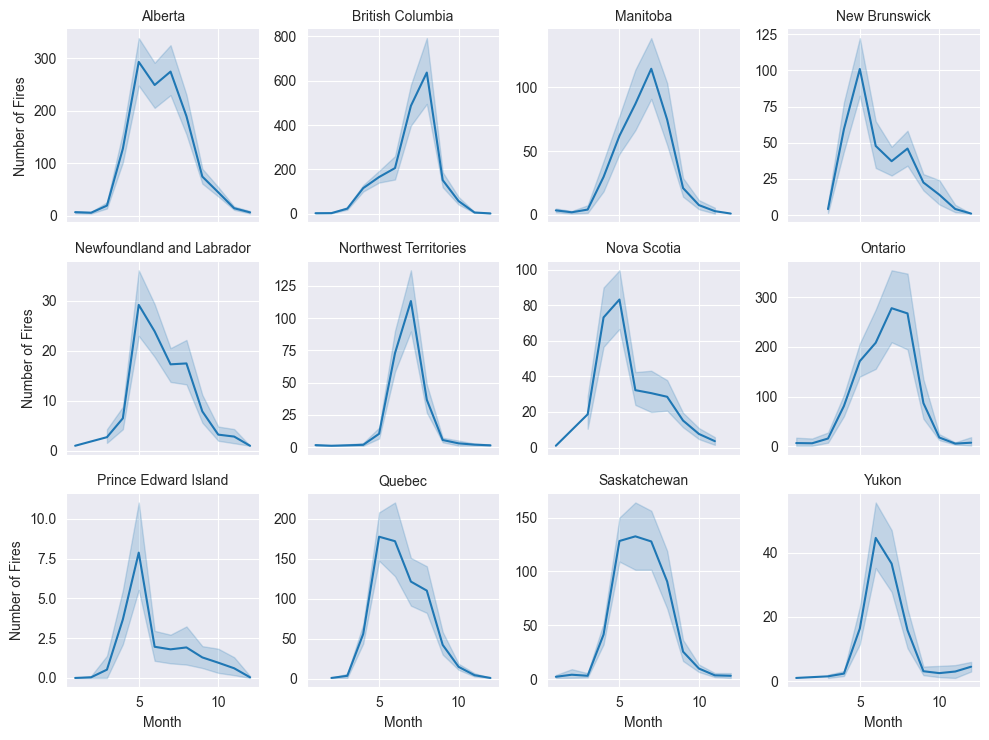

In [7]:
#monatlichen Brandzahlen über alle Provinzen
g = sns.FacetGrid(
    df_long,
    col="Jurisdiction",
    col_wrap=4,
    height=2.5,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="Month",
    y="Number_fires"
)

g.set_titles("{col_name}")
g.set_axis_labels("Month", "Number of Fires")
plt.show()


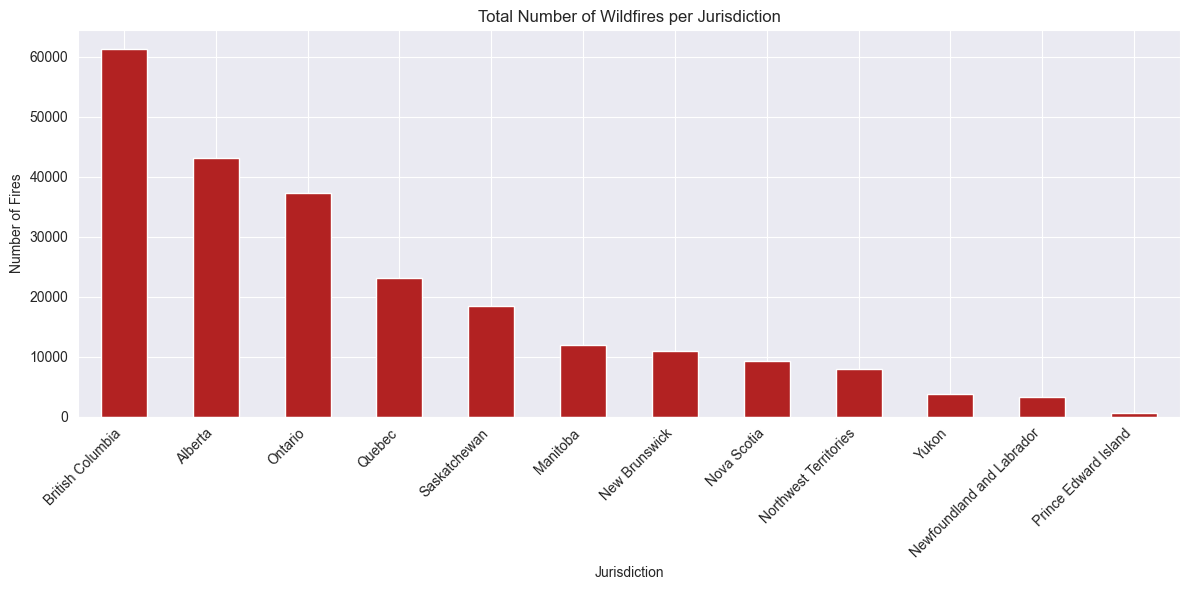

In [8]:
# Summe der Waldbrände pro Region berechnen
fires_per_region = (
    df_long.groupby("Jurisdiction")["Number_fires"]
           .sum()
           .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(12,6))
fires_per_region.plot(kind="bar", color="firebrick")

plt.title("Total Number of Wildfires per Jurisdiction")
plt.ylabel("Number of Fires")
plt.xlabel("Jurisdiction")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Saisonale Muster

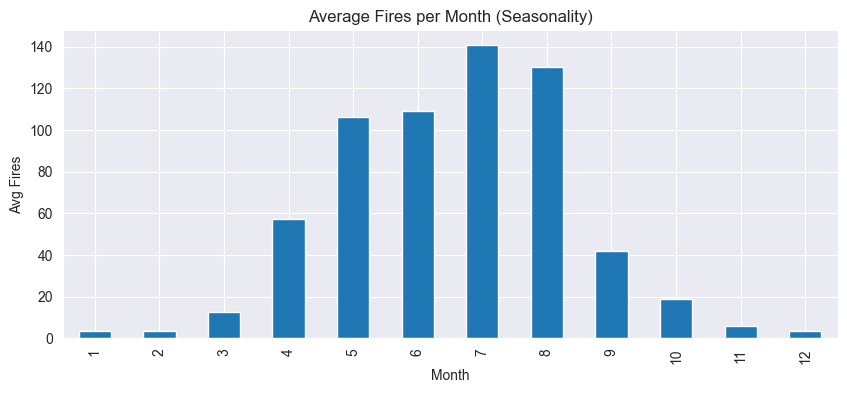

In [9]:
monthly_avg = df_long.groupby("Month")["Number_fires"].mean()

plt.figure(figsize=(10,4))
monthly_avg.plot(kind="bar")
plt.title("Average Fires per Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Avg Fires")
plt.show()


<Figure size 1200x500 with 0 Axes>

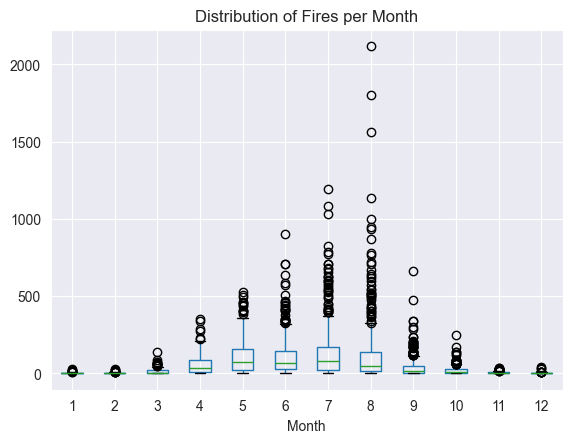

In [10]:
plt.figure(figsize=(12,5))
df_long.boxplot(column="Number_fires", by="Month")
plt.title("Distribution of Fires per Month")
plt.suptitle("")
plt.show()

<Figure size 1200x500 with 0 Axes>

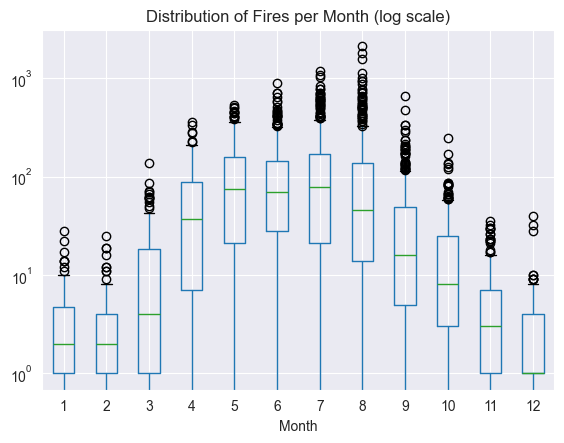

In [11]:
#Log-Skala
plt.figure(figsize=(12,5))
df_long.boxplot(column="Number_fires", by="Month")
plt.yscale("log")
plt.title("Distribution of Fires per Month (log scale)")
plt.suptitle("")
plt.show()

Heatmap Jahr x Monat

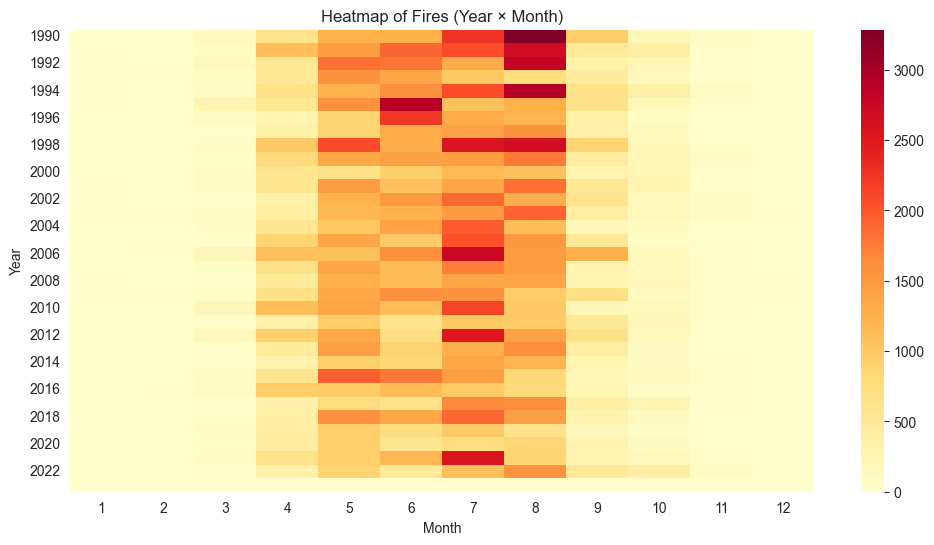

In [12]:
pivot = df_long.pivot_table(
    index="Year",
    columns="Month",
    values="Number_fires",
    aggfunc="sum"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Heatmap of Fires (Year × Month)")
plt.show()

Autokorrelation

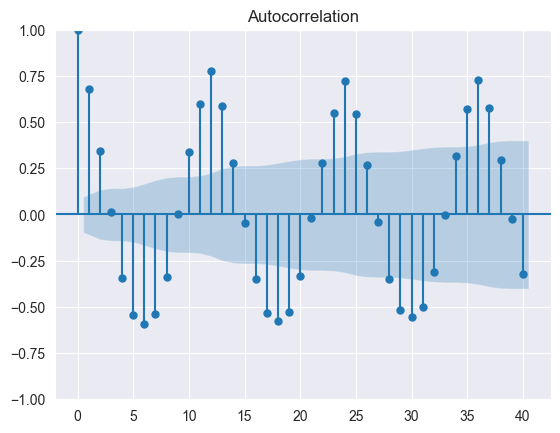

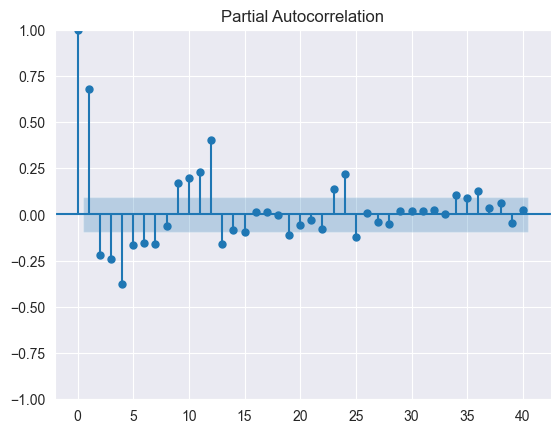

In [13]:
# Kanada-gesamt Zeitreihe
ts_total_sorted = ts_total.sort_values("Date")

plot_acf(ts_total_sorted["Number_fires"].dropna(), lags=40)
plt.show()

plot_pacf(ts_total_sorted["Number_fires"].dropna(), lags=40)
plt.show()

Ausreißer identifizieren

<Figure size 1200x600 with 0 Axes>

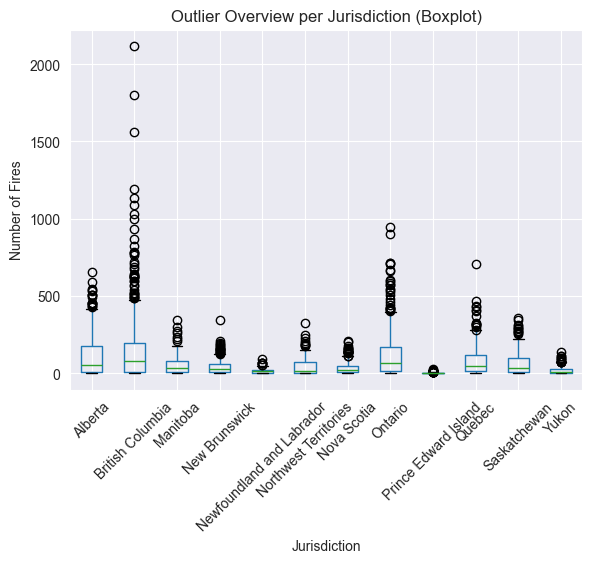

In [14]:
plt.figure(figsize=(12,6))
df_long.boxplot(column="Number_fires", by="Jurisdiction", rot=45)
plt.title("Outlier Overview per Jurisdiction (Boxplot)")
plt.suptitle("")
plt.xlabel("Jurisdiction")
plt.ylabel("Number of Fires")
plt.show()

# 5. Feature Engineering

In [15]:
# Datentypen anpassen
df_long["Year"] = df_long["Year"].astype(int)

# Anzahl (Number_fires) als ganze Zahl
df_long["Number_fires"] = pd.to_numeric(df_long["Number_fires"], errors="coerce").astype("Int64")

# Jurisdiction als Kategorie
df_long["Jurisdiction"] = df_long["Jurisdiction"].astype("category")

# Lag hinzufügen, vorherige Werte merken
df_long = df_long.sort_values(["Jurisdiction", "Year", "Month"])

df_long["Lag_1"] = df_long.groupby("Jurisdiction",observed=True)["Number_fires"].shift(1)
df_long["Lag_2"] = df_long.groupby("Jurisdiction",observed=True)["Number_fires"].shift(2)
df_long["Lag_3"] = df_long.groupby("Jurisdiction",observed=True)["Number_fires"].shift(3)

# Rolling / Window Features (gleitende Statistiken)
# Berechnung erfolgt pro Jurisdiction, um regionale Unterschiede korrekt abzubilden

# Rolling Mean: Glättet kurzfristige Schwankungen
df_long["RollMean_3"]  = df_long.groupby("Jurisdiction",observed=True)["Number_fires"].transform(lambda x: x.rolling(window=3,  min_periods=3).mean())
df_long["RollMean_6"]  = df_long.groupby("Jurisdiction",observed=True)["Number_fires"].transform(lambda x: x.rolling(window=6,  min_periods=3).mean())
df_long["RollMean_12"] = df_long.groupby("Jurisdiction",observed=True)["Number_fires"].transform(lambda x: x.rolling(window=12, min_periods=3).mean())

# Rolling Standard Deviation: Erfasst lokale Volatilität
df_long["RollStd_3"]  = df_long.groupby("Jurisdiction",observed=True)["Number_fires"].transform(lambda x: x.rolling(window=3,  min_periods=3).std())
df_long["RollStd_6"]  = df_long.groupby("Jurisdiction",observed=True)["Number_fires"].transform(lambda x: x.rolling(window=6,  min_periods=3).std())
df_long["RollStd_12"] = df_long.groupby("Jurisdiction",observed=True)["Number_fires"].transform(lambda x: x.rolling(window=12, min_periods=3).std())

# Rolling Sum: Gesamtanzahl der letzten Monate
df_long["RollSum_3"]  = df_long.groupby("Jurisdiction",observed=True)["Number_fires"].transform(lambda x: x.rolling(window=3,  min_periods=3).sum())
df_long["RollSum_6"]  = df_long.groupby("Jurisdiction",observed=True)["Number_fires"].transform(lambda x: x.rolling(window=6,  min_periods=3).sum())
df_long["RollSum_12"] = df_long.groupby("Jurisdiction",observed=True)["Number_fires"].transform(lambda x: x.rolling(window=12, min_periods=3).sum())

# Trigonometrisches Encoding für Monat (1–12)
df_long["Month_sin"] = np.sin(2 * np.pi * df_long["Month"] / 12)
df_long["Month_cos"] = np.cos(2 * np.pi * df_long["Month"] / 12)

# One Hot Encoding
df_long["Jurisdiction_raw"] = df_long["Jurisdiction"].astype(str)
df_long = pd.get_dummies(df_long, columns=["Jurisdiction"], prefix="REG", drop_first=False)
reg_cols = [col for col in df_long.columns if col.startswith("REG")]
df_long[reg_cols] = df_long[reg_cols].astype(int)

# Kontrolle
df_long[["Month", "Month_sin", "Month_cos"]].head(12)
df_long[["Number_fires", "Lag_1", "RollMean_3", "RollStd_6"]].head(15)
print(df_long.head(20))
print(df_long.dtypes)
df_fires = df_long.copy()

     Month  Year  Number_fires  Lag_1  Lag_2  Lag_3  RollMean_3  RollMean_6  \
0        1  1990             1   <NA>   <NA>   <NA>         NaN         NaN   
1        2  1990             5      1   <NA>   <NA>         NaN         NaN   
2        3  1990             8      5      1   <NA>    4.666667    4.666667   
3        4  1990            26      8      5      1   13.000000   10.000000   
4        5  1990           114     26      8      5   49.333333   30.800000   
5        6  1990           214    114     26      8  118.000000   61.333333   
6        7  1990           446    214    114     26  258.000000  135.500000   
7        8  1990           381    446    214    114  347.000000  198.166667   
8        9  1990           117    381    446    214  314.666667  216.333333   
9       10  1990            34    117    381    446  177.333333  217.666667   
10      11  1990            16     34    117    381   55.666667  201.333333   
11      12  1990             4     16     34    117 

In [16]:
#Datei speichern
#output_path = "../data/cleaned_Number_of_fires_by_month.csv"
#df_long.to_csv(output_path, index=False)

# 6. Merge Wetterdaten (alle Provinzen zusammenführen)

In [17]:
# Spalte time löschen und alle Wettertabellen zu einem Datenset mergen
province_files = {
    "Alberta": "../data/cleaned_Alberta_monthly_mean.csv",
    "British Columbia": "../data/cleaned_British_Columbia_monthly_mean.csv",
    "Manitoba": "../data/cleaned_Manitoba_monthly_mean.csv",
    "New Brunswick": "../data/cleaned_New_Brunswick_monthly_mean.csv",
    "Newfoundland and Labrador": "../data/cleaned_Newfoundland_and_Labrador_monthly_mean.csv",
    "Northwest Territories": "../data/cleaned_Northwest_Territories_monthly_mean.csv",
    "Nova Scotia": "../data/cleaned_Nova_Scotia_monthly_mean.csv",
    "Ontario": "../data/cleaned_Ontario_monthly_mean.csv",
    "Prince Edward Island": "../data/cleaned_Prince_Edward_Island_monthly_mean.csv",
    "Quebec": "../data/cleaned_Quebec_monthly_mean.csv",
    "Saskatchewan": "../data/cleaned_Saskatchewan_monthly_mean.csv",
    "Yukon": "../data/cleaned_Yukon_monthly_mean.csv"
}

weather_dfs = []

for province, path in province_files.items():
    df = pd.read_csv(path)

    if "time" in df.columns:
        df = df.drop(columns=["time"])

    df["Year"] = df["Year"].astype(int)
    df["Month"] = df["Month"].astype(int)
    df["Jurisdiction_raw"] = province

    weather_dfs.append(df)

# Alle Wetterdaten in eine Tabelle
df_weather_all = pd.concat(weather_dfs, ignore_index=True)
# Speichern des DataFrames als CSV-Datei
#df_weather_all.to_csv("../data/weather_all.csv", index=False)

print(df_weather_all.shape)
print(df_weather_all.columns)

(4764, 13)
Index(['temperature_2m_mean (°C)', 'temperature_2m_max (°C)',
       'relative_humidity_2m_mean (%)', 'relative_humidity_2m_min (%)',
       'precipitation_sum (mm)', 'precipitation_hours (h)',
       'wind_speed_10m_mean (km/h)', 'wind_speed_10m_max (km/h)',
       'wind_direction_10m_dominant (°)', 'et0_fao_evapotranspiration (mm)',
       'Year', 'Month', 'Jurisdiction_raw'],
      dtype='object')


In [18]:
# Spalten löschen aufgrund der Korrel. Analyse (Finale Feature Definition)
cols_to_drop = [
    "precipitation_sum (mm)",
    "precipitation_hours (h)",
    "wind_speed_10m_mean (km/h)",
    "wind_speed_10m_max (km/h)",
    "wind_direction_10m_dominant (°)"
]

df_weather = df_weather_all.drop(
    columns=[c for c in cols_to_drop if c in df_weather_all.columns]
)
print(df_weather.columns)
print(df_weather.dtypes)


Index(['temperature_2m_mean (°C)', 'temperature_2m_max (°C)',
       'relative_humidity_2m_mean (%)', 'relative_humidity_2m_min (%)',
       'et0_fao_evapotranspiration (mm)', 'Year', 'Month', 'Jurisdiction_raw'],
      dtype='object')
temperature_2m_mean (°C)           float64
temperature_2m_max (°C)            float64
relative_humidity_2m_mean (%)      float64
relative_humidity_2m_min (%)       float64
et0_fao_evapotranspiration (mm)    float64
Year                                 int64
Month                                int64
Jurisdiction_raw                    object
dtype: object


# 6. Merge Wetterdaten & Anzahl Brände

In [19]:
# Number of fires laden
#df_fires = pd.read_csv("../data/cleaned_Number_of_fires_by_month.csv")

#Finaler Merge
df_merged = pd.merge(
    df_fires,
    df_weather_all,
    on=["Jurisdiction_raw", "Year", "Month"],
    how="inner"
)

print(df_merged.shape)
print(df_merged.isna().sum())
print(df_merged.head())

# Speichern des DataFrames als CSV-Datei
#df_merged.to_csv("../data/final_data.csv", index=False)

(4498, 40)
Month                                 0
Year                                  0
Number_fires                       1264
Lag_1                              1266
Lag_2                              1271
Lag_3                              1279
RollMean_3                         1979
RollMean_6                          758
RollMean_12                         142
RollStd_3                          1979
RollStd_6                           758
RollStd_12                          142
RollSum_3                          1979
RollSum_6                           758
RollSum_12                          142
Month_sin                             0
Month_cos                             0
Jurisdiction_raw                      0
REG_Alberta                           0
REG_British Columbia                  0
REG_Manitoba                          0
REG_New Brunswick                     0
REG_Newfoundland and Labrador         0
REG_Northwest Territories             0
REG_Nova Scotia              

# 7. Feature Engineering Wetterdaten + Vorbereitung für den Split

In [20]:
df_merged = df_merged.sort_values(["Jurisdiction_raw", "Year", "Month"])

weather_features = [
    "temperature_2m_mean (°C)",
    "relative_humidity_2m_mean (%)",
    "et0_fao_evapotranspiration (mm)"
]

for col in weather_features:
    df_merged[f"{col}_lag1"] = (
        df_merged.groupby("Jurisdiction_raw")[col].shift(1)
    )

# Speichern des DataFrames als CSV-Datei
#df_merged.to_csv("../data/final_data.csv", index=False)

In [21]:
# Number of fires als Zielvariabel setzen und NaNs in Number of fires löschen
target = "Number_fires"
df_model = df_merged[df_merged[target].notna()].copy()
#df_model.to_csv("../data/final_data.csv", index=False)

In [22]:
#df_model = pd.read_csv("../data/final_data.csv")

target = "Number_fires"

X = df_model.drop(columns=[target])
y = df_model[target]


# 8. Train/ Test Split

In [23]:
# Training: ca. 60% der Zeit (1990–2012), Validation: ca. 20 % (2013–2017), Test: ca. 20 % (2018–2023)
# Features / Target
import joblib
X = df_model.drop(columns=["Number_fires"])
y = df_model["Number_fires"]

# Zeitbasierter Split (mit Kopien!)
X_train = X[X["Year"] <= 2012].copy()
y_train = y[X["Year"] <= 2012].copy()

X_val = X[(X["Year"] > 2012) & (X["Year"] <= 2017)].copy()
y_val = y[(X["Year"] > 2012) & (X["Year"] <= 2017)].copy()

X_test = X[X["Year"] > 2017].copy()
y_test = y[X["Year"] > 2017].copy()

# Imputation
num_cols = X_train.select_dtypes(include=["number"]).columns

imputer = SimpleImputer(strategy="median")

X_train.loc[:, num_cols] = imputer.fit_transform(X_train.loc[:, num_cols])
joblib.dump(imputer, "../backend/imputer.joblib")
print("IMPUTER GESPEICHERT")
X_val.loc[:, num_cols]   = imputer.transform(X_val.loc[:, num_cols])
X_test.loc[:, num_cols]  = imputer.transform(X_test.loc[:, num_cols])


print(X_train["Year"].max(), X_test["Year"].min())

IMPUTER GESPEICHERT
2012 2018


In [24]:
# Jurisdiction raw entfernen
X_train = X_train.drop(columns=["Jurisdiction_raw"])
X_val   = X_val.drop(columns=["Jurisdiction_raw"])
X_test  = X_test.drop(columns=["Jurisdiction_raw"])

# 9. Baseline trainieren - Random Forest

In [25]:
from sklearn.ensemble import RandomForestRegressor
#Random-Forest-Baseline definieren
rf_baseline = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

In [26]:
#Modell trainieren
rf_baseline.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
#Vorhersage trainieren
y_pred_train = rf_baseline.predict(X_train)
y_pred_val   = rf_baseline.predict(X_val)
y_pred_test  = rf_baseline.predict(X_test)

# 10. Baseline Modell evaluieren - Random Forest

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate(y_train, y_pred_train, "Train")
evaluate(y_val,   y_pred_val,   "Validation")
evaluate(y_test,  y_pred_test,  "Test")


Train → MAE: 7.41, RMSE: 17.01
Validation → MAE: 18.15, RMSE: 32.81
Test → MAE: 19.51, RMSE: 34.40


# 9a Baseline trainieren - XGBoost

In [29]:
from xgboost import XGBRegressor
# Baseline definieren
xgb_baseline = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [30]:
# Baseline Modell trainieren
xgb_baseline.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [31]:
#Vorhersagen erzeugen
y_pred_train_xgb = xgb_baseline.predict(X_train)
y_pred_val_xgb   = xgb_baseline.predict(X_val)
y_pred_test_xgb  = xgb_baseline.predict(X_test)

# 10a Baseline evaluieren - XG Boost

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate(y_train, y_pred_train_xgb, "Train")
evaluate(y_val,   y_pred_val_xgb,   "Validation")
evaluate(y_test,  y_pred_test_xgb,  "Test")


Train → MAE: 3.52, RMSE: 5.17
Validation → MAE: 15.17, RMSE: 28.04
Test → MAE: 16.08, RMSE: 28.31


# 11. Modellauswahl

Der XGBoost-Regressor erzielte gegenüber dem Random-Forest-Modell eine deutlich niedrigere MAE und RMSE und zeigte insbesondere bei der Vorhersage von Extremwerten eine verbesserte Performance.

# 12. Optimierung

In [33]:
#Hyperparameter Tuning

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

configs = {
    "baseline": {
        "max_depth": 6,
        "learning_rate": 0.05,
        "min_child_weight": 1
    },
    "regularized_depth5": {
        "max_depth": 5,
        "learning_rate": 0.05,
        "min_child_weight": 3
    },
    "regularized_depth4": {
        "max_depth": 4,
        "learning_rate": 0.03,
        "min_child_weight": 5
    }
}


In [34]:
#Evaluation
results = []

for name, cfg in configs.items():
    model = XGBRegressor(
        n_estimators=400,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **cfg
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_val_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_val_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    results.append((name, mae, rmse))

    print(f"{name} → Val MAE: {mae:.2f}, Val RMSE: {rmse:.2f}")


baseline → Val MAE: 14.99, Val RMSE: 27.81
regularized_depth5 → Val MAE: 15.82, Val RMSE: 29.15
regularized_depth4 → Val MAE: 18.18, Val RMSE: 31.12


# 13. Training & Evaluation

In [35]:
from xgboost import XGBRegressor

# Train + Validation zusammenführen
X_final = pd.concat([X_train, X_val])
y_final = pd.concat([y_train, y_val])

final_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_final, y_final)

y_test_pred = final_model.predict(X_test)

# 14. Interpretation & Ergebnisse

In [36]:
#Feature Importance
importance = final_model.get_booster().get_score(importance_type="gain")

# In DataFrame umwandeln
imp_df = (
    pd.DataFrame(importance.items(), columns=["Feature", "Gain"])
    .sort_values(by="Gain", ascending=False)
)
print(imp_df.head(15))

                            Feature           Gain
11                        RollSum_3  199268.828125
5                        RollMean_3  195335.875000
28          temperature_2m_max (°C)  154628.359375
9                         RollStd_6   74055.359375
30     relative_humidity_2m_min (%)   52552.890625
36  et0_fao_evapotranspiration (mm)   36126.476562
8                         RollStd_3   34752.847656
27         temperature_2m_mean (°C)   24236.595703
15                        Month_cos   20606.613281
7                       RollMean_12   19161.343750
29    relative_humidity_2m_mean (%)   14905.055664
6                        RollMean_6   13442.982422
13                       RollSum_12   11287.721680
3                             Lag_2    9055.954102
14                        Month_sin    9038.479492


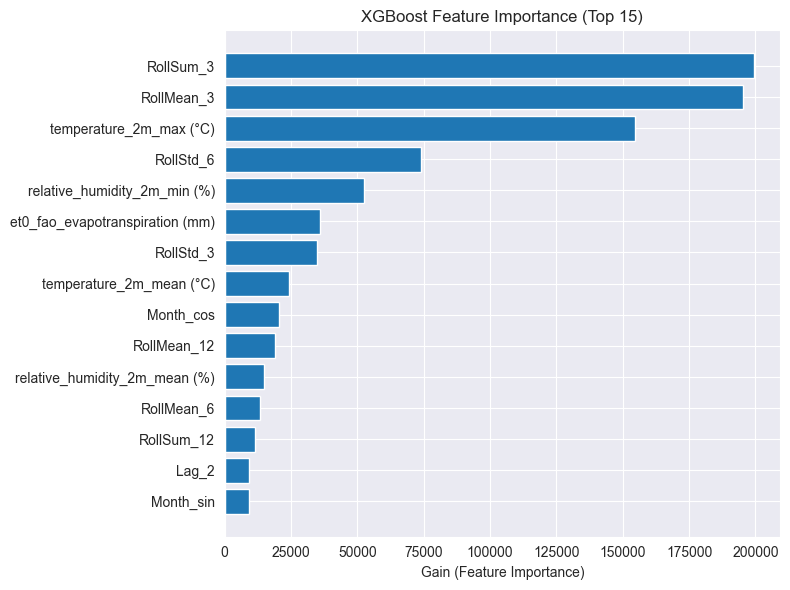

In [37]:
top_n = 15
plt.figure(figsize=(8, 6))
plt.barh(
    imp_df["Feature"].head(top_n)[::-1],
    imp_df["Gain"].head(top_n)[::-1]
)
plt.xlabel("Gain (Feature Importance)")
plt.title("XGBoost Feature Importance (Top 15)")
plt.tight_layout()
plt.show()


In [38]:
#Testdaten mit Zeitinformation
# Vorhersagen
y_test_pred = final_model.predict(X_test)

# Analyse-DataFrame
df_errors = X_test.copy()
df_errors["y_true"] = y_test.values
df_errors["y_pred"] = y_test_pred
df_errors["error"] = df_errors["y_true"] - df_errors["y_pred"]
df_errors["abs_error"] = np.abs(df_errors["error"])

# Sortieren nach Zeit (wichtig!)
df_errors = df_errors.sort_values(["Year", "Month"])

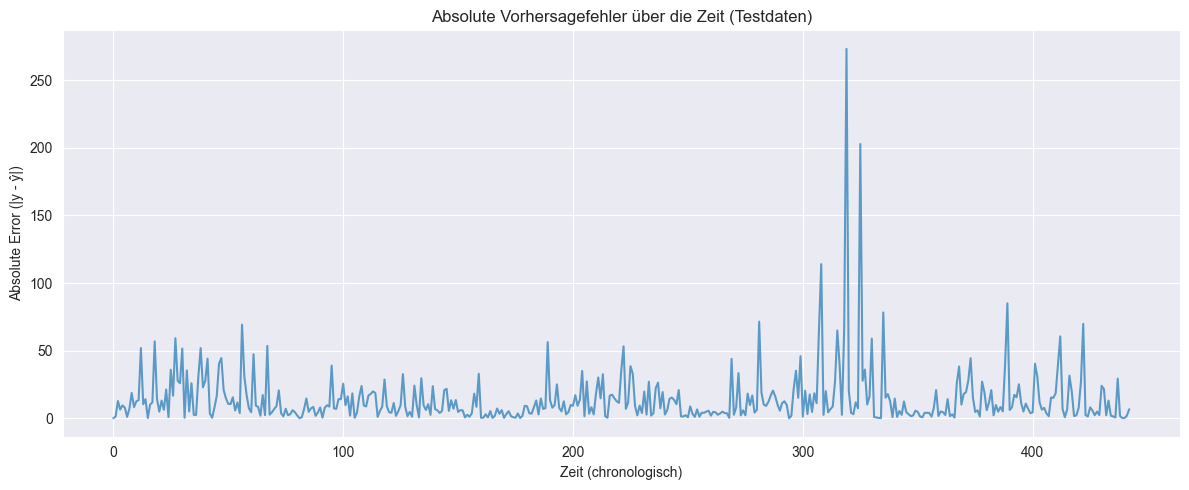

In [39]:
# Fehler über die Zeit visualisieren
plt.figure(figsize=(12, 5))
plt.plot(
    range(len(df_errors)),
    df_errors["abs_error"],
    label="Absolute Error",
    alpha=0.7
)
plt.ylabel("Absolute Error (|y - ŷ|)")
plt.xlabel("Zeit (chronologisch)")
plt.title("Absolute Vorhersagefehler über die Zeit (Testdaten)")
plt.tight_layout()
plt.show()

In [40]:
#Fehler nach Jahreszeit analysieren (Sommer vs. Rest)
def season_from_month(m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Spring"
    elif m in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df_errors["Season"] = df_errors["Month"].apply(season_from_month)

In [41]:
season_error = (
    df_errors
    .groupby("Season")["abs_error"]
    .mean()
    .sort_values(ascending=False)
)

print(season_error)

Season
Summer    20.163625
Spring    12.714443
Fall        10.3261
Winter     3.331141
Name: abs_error, dtype: Float64


In [42]:
#Analyse der Extremmonate (wo schwächelt das Modell?)
df_errors.nlargest(10, "abs_error")[
    ["Year", "Month", "y_true", "y_pred", "abs_error"]
]


,Year,Month,y_true,y_pred,abs_error
776,2021,8,263,536.094360,273.09436
2959,2021,8,123,325.788513,202.788513
775,2021,7,784,670.032043,113.967957
3730,2022,6,21,105.971718,84.971718
2960,2021,9,16,94.196327,78.196327
2955,2021,4,29,100.422981,71.422981
790,2022,10,169,99.184303,69.815697
2923,2018,8,300,369.223022,69.223022
379,2021,8,175,241.384674,66.384674
3720,2021,7,37,101.900368,64.900368


# 15. Export der Modelle/Plots

In [43]:
import joblib

model_path = "../models/xgboost_final_model.joblib"
joblib.dump(final_model, model_path)

print("Modell erfolgreich gespeichert:", model_path)

Modell erfolgreich gespeichert: ../models/xgboost_final_model.joblib


In [44]:
#feature namen seperat speichern
feature_path = "../models/xgboost_features.joblib"
joblib.dump(list(X_final.columns), feature_path)

print("Feature-Liste gespeichert.")

Feature-Liste gespeichert.


In [45]:
#Modell wieder laden
loaded_model = joblib.load("../models/xgboost_final_model.joblib")
loaded_features = joblib.load("../models/xgboost_features.joblib")

# Beispiel-Vorhersage
y_test_pred_loaded = loaded_model.predict(X_test[loaded_features])